In [6]:
# Ensure you have at least 2GB free space in Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Project setup
import os
PROJECT_DIR = "/content/drive/MyDrive/DL_Group_MGI1"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print("Working in:", os.getcwd())

# Install dependencies
!pip install -q  matplotlib  pathlib 

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working in: /content/drive/MyDrive/DL_Group_MGI1


In [2]:
# Run this everytime you update something in the repo!
REPO = "https://github.com/gabrielcastrob/Deep_learning_WUR"

# if project directory is empty clone the repo, otherwise pull the latest changes
if not os.listdir(PROJECT_DIR):
    !git clone {REPO} {PROJECT_DIR}
else:
    !git -C {PROJECT_DIR} pull

%cd {PROJECT_DIR}
print("Working in:", os.getcwd())

remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 12 (delta 6), reused 11 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (12/12), 5.00 MiB | 4.14 MiB/s, done.
From https://github.com/gabrielcastrob/Deep_learning_WUR
   1f7e4e6..1af69e8  main       -> origin/main
Updating 1f7e4e6..1af69e8
error: invalid object 100644 c1e02d13034ebaf53a2dcd0806c460a5d3aad224 for 'GRS_34806_MGI_Project.ipynb'
Fast-forward
 notebooks/00_ML_Resnet.ipynb |  371 ++++++-----
 notebooks/00_ML_ViT.ipynb    |  957 ++++++++++++++++++++++++++++
 notebooks/01_ML_ViT.ipynb    | 1451 ++++++------------------------------------
 utils.py                     |   95 +--
 4 files changed, 1348 insertions(+), 1526 deletions(-)
 create mode 100644 notebooks/00_ML_ViT.ipynb
/content
Working in: /content/drive/MyDrive/DL_Group_MGI1


In [3]:
import shutil, zipfile
import subprocess
import importlib
  


import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.models as tvm
import matplotlib.pyplot as plt


import pytorch_lightning as L
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

from pytorch_lightning.loggers import CSVLogger


# utility functions
import utils


L.seed_everything(42, workers=True)
DEVICE = "gpu" if torch.cuda.is_available() else "cpu"
print("Accelerator:", DEVICE)
if DEVICE == "gpu":
    print("GPU:", torch.cuda.get_device_name(0))

# After git pull, reload utils to get the latest changes without restarting the notebook
importlib.reload(utils)

/content/drive/MyDrive/DL_Group_MGI1/utils.py:26: SyntaxWarning: invalid escape sequence '\L'
  IMAGE\LABEL   airplane   bare-soil   buildings   …   water
INFO:lightning_fabric.utilities.seed:Seed set to 42


Accelerator: gpu
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


<module 'utils' from '/content/drive/MyDrive/DL_Group_MGI1/utils.py'>

In [4]:
Model_R = "ResNet50"
Model_V = "ViTB16"
classes = ['airplane','bare-soil','buildings','cars','chaparral','court','dock','field',
            'grass','mobile-home','pavement','sand','sea','ship','tanks','trees','water']

In [5]:
# load the probs preds and labels
output_df_R = pd.read_csv(f"outputs/{Model_R}_multilabel_test_results.csv")
test_preds_R = output_df_R[[f"{c}_pred" for c in classes]].values
test_labels_R = output_df_R[[f"{c}_label" for c in classes]].values
test_probs_R = output_df_R[[f"{c}_prob" for c in classes]].values

output_df_V = pd.read_csv(f"outputs/{Model_V}_multilabel_test_results.csv")
test_preds_V = output_df_V[[f"{c}_pred" for c in classes]].values
test_labels_V = output_df_V[[f"{c}_label" for c in classes]].values
test_probs_V = output_df_V[[f"{c}_prob" for c in classes]].values


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, average_precision_score
from pathlib import Path

def plot_per_class_metrics_comparison(
    test_labels1, test_preds1, test_probs1, 
    test_labels2, test_preds2, test_probs2,
    classes, 
    model_name1: str = "Model 1",
    model_name2: str = "Model 2",
    save_path: str = None, 
    csv_output: str = None):
    """
    Plot per-class F1 and AP metrics for 2 models with grouped bars (separate figures).
    
    Args:
        test_labels1/2: Ground truth labels, shape (N, C)
        test_preds1/2: Predicted labels, shape (N, C)
        test_probs1/2: Predicted probabilities, shape (N, C)
        classes: List of class names
        model_name1/2: Names for the models
        save_path: Optional path to save the figures (will add _f1.png and _ap.png)
        csv_output: Optional path to save comparison CSV
    
    Returns:
        tuple: (fig_f1, ax_f1, fig_ap, ax_ap, summary_df) with comparison results
    """
    
    # Compute per-class metrics for both models
    per_class_f1_1 = f1_score(test_labels1, test_preds1, average=None, zero_division=0)
    per_class_ap_1 = average_precision_score(test_labels1, test_probs1, average=None)
    
    per_class_f1_2 = f1_score(test_labels2, test_preds2, average=None, zero_division=0)
    per_class_ap_2 = average_precision_score(test_labels2, test_probs2, average=None)
    
    positives = test_labels1.sum(axis=0).astype(int)
    num_classes = len(classes)
    
    # Sort by positives (descending)
    order = np.argsort(-positives)
    classes_sorted = [classes[i] for i in order]
    f1_1_sorted = per_class_f1_1[order]
    ap_1_sorted = per_class_ap_1[order]
    f1_2_sorted = per_class_f1_2[order]
    ap_2_sorted = per_class_ap_2[order]
    pos_sorted = positives[order]
    
    x = np.arange(num_classes)
    width = 0.35  # Width of each bar
    
    # Figure 1: F1 Scores
    fig_f1, ax_f1 = plt.subplots(figsize=(max(12, 0.8 * num_classes), 6))
    ax_f1.bar(x - width/2, f1_1_sorted, width, label=f"{model_name1} F1", color="steelblue")
    ax_f1.bar(x + width/2, f1_2_sorted, width, label=f"{model_name2} F1", color="coral")
    ax_f1.set_xticks(x)
    ax_f1.set_xticklabels(classes_sorted, rotation=45, ha="right")
    ax_f1.set_ylim(0, 1)
    ax_f1.set_ylabel("F1 Score")
    ax_f1.set_title(f"{model_name1} vs {model_name2} — Per-class F1 Comparison")
    ax_f1.legend(loc="lower right", fontsize=10)
    ax_f1.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        f1_path = save_path.replace(".png", "_f1.png")
        Path(f1_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(f1_path, dpi=150, bbox_inches="tight")
        print(f"Saved F1 comparison plot to: {f1_path}")
    
    plt.show()
    
    # Figure 2: AP Scores
    fig_ap, ax_ap = plt.subplots(figsize=(max(12, 0.8 * num_classes), 6))
    ax_ap.bar(x - width/2, ap_1_sorted, width, label=f"{model_name1} AP", color="lightblue")
    ax_ap.bar(x + width/2, ap_2_sorted, width, label=f"{model_name2} AP", color="lightsalmon")
    ax_ap.set_xticks(x)
    ax_ap.set_xticklabels(classes_sorted, rotation=45, ha="right")
    ax_ap.set_ylim(0, 1)
    ax_ap.set_ylabel("Average Precision")
    ax_ap.set_title(f"{model_name1} vs {model_name2} — Per-class AP Comparison")
    ax_ap.legend(loc="lower right", fontsize=10)
    ax_ap.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        ap_path = save_path.replace(".png", "_ap.png")
        Path(ap_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(ap_path, dpi=150, bbox_inches="tight")
        print(f"Saved AP comparison plot to: {ap_path}")
    
    plt.show()
    
    # Summary DataFrame with both models
    summary = pd.DataFrame({
        "class": classes_sorted,
        "positives": pos_sorted,
        f"{model_name1} F1": f1_1_sorted.round(4),
        f"{model_name1} AP": ap_1_sorted.round(4),
        f"{model_name2} F1": f1_2_sorted.round(4),
        f"{model_name2} AP": ap_2_sorted.round(4),
    })
    
    print("\nPer-class Comparison:")
    print(summary.to_string(index=False))
    
    if csv_output:
        Path(csv_output).parent.mkdir(parents=True, exist_ok=True)
        summary.to_csv(csv_output, index=False)
        print(f"Saved comparison table to: {csv_output}")
    
    return fig_f1, ax_f1, fig_ap, ax_ap, summary

Saved F1 comparison plot to: outputs/model_comparison_f1.png


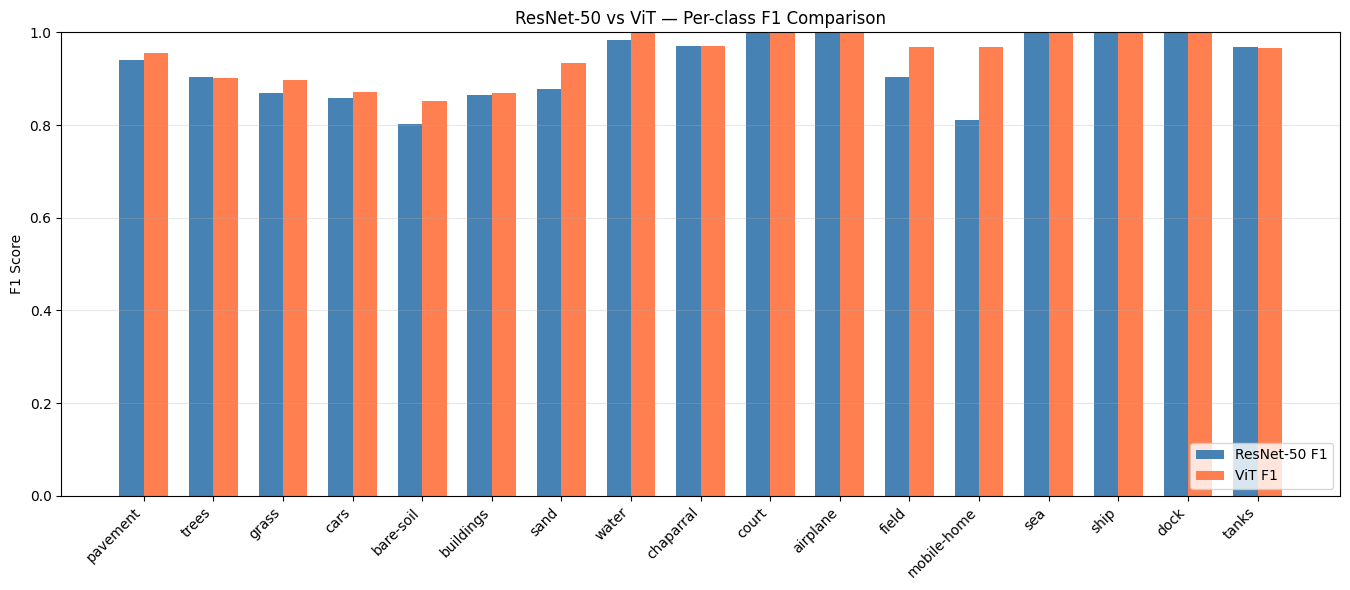

Saved AP comparison plot to: outputs/model_comparison_ap.png


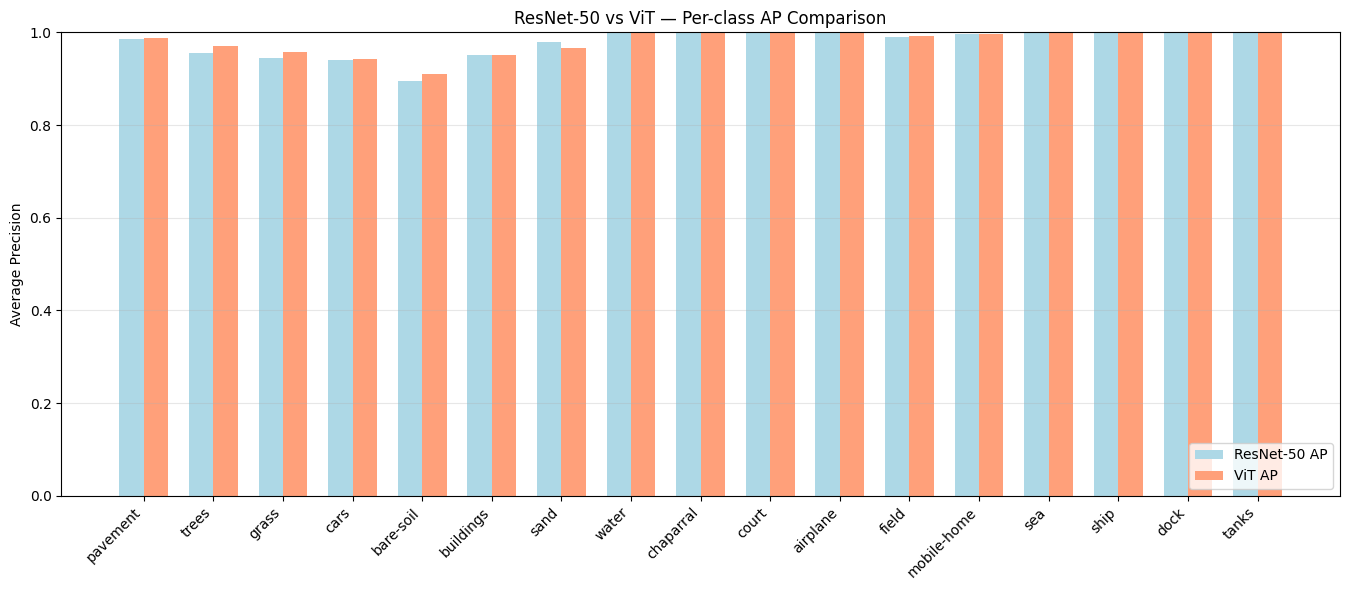


Per-class Comparison:
      class  positives  ResNet-50 F1  ResNet-50 AP  ViT F1  ViT AP
   pavement        201        0.9395        0.9863  0.9561  0.9871
      trees        151        0.9038        0.9561  0.9013  0.9713
      grass        146        0.8699        0.9437  0.8973  0.9575
       cars        133        0.8592        0.9392  0.8723  0.9418
  bare-soil        108        0.8017        0.8958  0.8520  0.9092
  buildings        104        0.8641        0.9513  0.8692  0.9520
       sand         44        0.8776        0.9788  0.9348  0.9658
      water         30        0.9836        1.0000  1.0000  1.0000
  chaparral         17        0.9714        1.0000  0.9714  1.0000
      court         16        1.0000        1.0000  1.0000  1.0000
   airplane         15        1.0000        1.0000  1.0000  1.0000
      field         15        0.9032        0.9889  0.9677  0.9914
mobile-home         15        0.8108        0.9958  0.9677  0.9958
        sea         15        1.0000   

In [ ]:
fig_f1, ax_f1, fig_ap, ax_ap, summary = plot_per_class_metrics_comparison(
    test_labels_R, test_preds_R, test_probs_R,
    test_labels_V, test_preds_V, test_probs_V,
    classes,
    model_name1="ResNet-50",
    model_name2="ViTB16",
    save_path="outputs/model_comparison.png",
    csv_output=None)